In [1]:
!nvidia-smi

Thu Oct  8 07:03:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:

from numba import cuda
import os

device = cuda.get_current_device()

name = device.name
if isinstance(name, bytes):
    name = name.decode("utf-8")

print(f"Device Name: {name}")
print(f"Compute Capability: {device.compute_capability}")
print(f"Multiprocessor Count (SMs): {getattr(device, 'MULTIPROCESSOR_COUNT', 'N/A')}")
print(f"Max Threads Per Block: {device.MAX_THREADS_PER_BLOCK}")
print(f"Max Block Dimensions: {device.MAX_BLOCK_DIM_X}, {device.MAX_BLOCK_DIM_Y}, {device.MAX_BLOCK_DIM_Z}")
print(f"Warp Size: {device.WARP_SIZE}")


Device Name: Tesla T4
Compute Capability: ComputeCapability(major=7, minor=5)
Multiprocessor Count (SMs): 40
Max Threads Per Block: 1024
Max Block Dimensions: 1024, 1024, 64
Warp Size: 32


In [3]:

import numpy as np
import time
from numba import cuda

# CPU
def double_cpu_pure(arr):
    out = np.empty_like(arr)
    for i in range(len(arr)):
        out[i] = arr[i] * 2.0
    return out

# GPU
@cuda.jit
def double_gpu_kernel(d_in, d_out):
    idx = cuda.grid(1)
    if idx < d_in.shape[0]:
        d_out[idx] = d_in[idx] * 2.0

print("CPU and GPU functions are ready!")


CPU and GPU functions are ready!


In [5]:

def benchmark_run(N, student_id_seed=230103136):
    np.random.seed(student_id_seed)
    h_in = np.random.rand(N).astype(np.float32)

    # CPU measurement
    if N <= 1_000_000:
        t0 = time.perf_counter()
        cpu_result = double_cpu_pure(h_in)
        cpu_time_ms = (time.perf_counter() - t0) * 1000
    else:
        cpu_time_ms = float('nan')

    threads_per_block = 256
    blocks_per_grid = (N + threads_per_block - 1) // threads_per_block


    d_warmup = cuda.to_device(np.ones(10, dtype=np.float32))
    double_gpu_kernel[1, 32](d_warmup, d_warmup)
    cuda.synchronize()


    t0 = time.perf_counter()
    d_in = cuda.to_device(h_in)
    d_out = cuda.device_array_like(d_in)

    double_gpu_kernel[blocks_per_grid, threads_per_block](d_in, d_out)
    h_out = d_out.copy_to_host()
    cuda.synchronize()

    gpu_total_ms = (time.perf_counter() - t0) * 1000


    t0 = time.perf_counter()
    double_gpu_kernel[blocks_per_grid, threads_per_block](d_in, d_out)
    cuda.synchronize()

    gpu_compute_ms = (time.perf_counter() - t0) * 1000

    return cpu_time_ms, gpu_total_ms, gpu_compute_ms


sizes = [100, 1000, 10000, 100000, 1000000, 5000000, 10000000]

results = []

print(f"{'N':<12} {'CPU (ms)':<15} {'GPU Total (ms)':<18} {'GPU Kernel (ms)':<18} {'Winner'}")
print("-" * 75)

for N in sizes:
    cpu, gpu_total, gpu_kernel = benchmark_run(N)

    if np.isnan(cpu):
        winner = "Not measured"
    else:
        winner = "GPU" if gpu_total < cpu else "CPU"

    results.append((N, cpu, gpu_total, gpu_kernel, winner))

    print(f"{N:<12} {cpu:<15.4f} {gpu_total:<18.4f} {gpu_kernel:<18.4f} {winner}")


N            CPU (ms)        GPU Total (ms)     GPU Kernel (ms)    Winner
---------------------------------------------------------------------------
100          0.0468          0.8158             0.8086             CPU
1000         0.4202          0.4524             0.0598             CPU
10000        2.7490          0.4959             0.1349             GPU
100000       26.9922         0.6486             0.0768             GPU
1000000      273.4733        4.7447             0.1165             GPU
5000000      nan             17.5924            0.3123             Not measured
10000000     nan             29.6224            0.5112             Not measured


Step 3 — Analysis Questions
Section 2
Q1. What is the empirical Crossover Point N?*
The empirical crossover point is N = 10,000. At this size, the GPU total execution time was 0.4959 ms, while the CPU execution time was 2.7490 ms. For smaller arrays, the CPU was faster because GPU overhead was relatively high.
Q2. Why is GPU Total Time slower at N = 100?
At N = 100, the CPU took 0.0468 ms, while the GPU total time was 0.8158 ms. The GPU kernel-only measurement was 0.8086 ms. This shows that the GPU was slower mainly because of launch and execution overhead for such a small workload. In this run, the difference between total and kernel-only measurements was only 0.0072 ms, so the results do not demonstrate that 95% of the time was spent on data transfers.

Section 3

In [6]:

from numba import cuda
import numpy as np

@cuda.jit
def defective_kernel(d_arr):
    idx = cuda.grid(1)
    d_arr[idx] = 999.0

N = 1000
h_arr = np.zeros(N, dtype=np.float32)
d_arr = cuda.to_device(h_arr)

threads_per_block = 256
blocks_per_grid = 4

print("Launching defective kernel with 1024 threads on 1000-element array...")

try:
    defective_kernel[blocks_per_grid, threads_per_block](d_arr)
    cuda.synchronize()

    h_result = d_arr.copy_to_host()
    print("Execution finished.")
    print(f"Elements processed: {len(h_result)}")
    print(f"Last element: {h_result[-1]}")

except Exception as e:
    print("CUDA Error:", type(e).__name__)
    print(str(e))


Launching defective kernel with 1024 threads on 1000-element array...
Execution finished.
Elements processed: 1000
Last element: 999.0


Task 3.1 — Observation
The defective kernel completed without displaying an error. It launched 1,024 threads for an array of 1,000 elements. The output showed 1,000 elements, and the last element was 999.0. Although no error occurred, the kernel attempted out-of-bounds memory writes because it did not include a boundary check.

In [7]:

@cuda.jit
def inspect_threads_kernel(log_block, log_thread, log_global, log_active, N):
    t_idx = cuda.threadIdx.x
    b_idx = cuda.blockIdx.x
    g_idx = cuda.grid(1)

    if g_idx < log_block.shape[0]:
        log_block[g_idx] = b_idx
        log_thread[g_idx] = t_idx
        log_global[g_idx] = g_idx
        log_active[g_idx] = 1 if g_idx < N else 0

N = 37
threads_per_block = 8
blocks_per_grid = (N + threads_per_block - 1) // threads_per_block

total_threads = blocks_per_grid * threads_per_block

log_b = cuda.device_array(total_threads, dtype=np.int32)
log_t = cuda.device_array(total_threads, dtype=np.int32)
log_g = cuda.device_array(total_threads, dtype=np.int32)
log_a = cuda.device_array(total_threads, dtype=np.int32)

inspect_threads_kernel[blocks_per_grid, threads_per_block](
    log_b, log_t, log_g, log_a, N
)

cuda.synchronize()


log_b = log_b.copy_to_host()
log_t = log_t.copy_to_host()
log_g = log_g.copy_to_host()
log_a = log_a.copy_to_host()

print(f"{'Global ID':<10} | {'Block ID':<10} | {'Thread ID':<10} | {'Status'}")
print("-" * 55)

for i in range(32, 40):
    status = "ACTIVE" if log_a[i] == 1 else "IDLE (GUARDED)"
    print(f"{log_g[i]:<10} | {log_b[i]:<10} | {log_t[i]:<10} | {status}")

print("\nGEOMETRY RESULTS")
print("Total Blocks:", blocks_per_grid)
print("Total Threads:", total_threads)
print("Active Threads:", N)
print("Idle Guarded Threads:", total_threads - N)


Global ID  | Block ID   | Thread ID  | Status
-------------------------------------------------------
32         | 4          | 0          | ACTIVE
33         | 4          | 1          | ACTIVE
34         | 4          | 2          | ACTIVE
35         | 4          | 3          | ACTIVE
36         | 4          | 4          | ACTIVE
37         | 4          | 5          | IDLE (GUARDED)
38         | 4          | 6          | IDLE (GUARDED)
39         | 4          | 7          | IDLE (GUARDED)

GEOMETRY RESULTS
Total Blocks: 5
Total Threads: 40
Active Threads: 37
Idle Guarded Threads: 3


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 5 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Section 4


In [8]:

import numpy as np
import time
from numba import cuda


@cuda.jit
def naive_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)
    if idx < d_arr.shape[0]:
        d_total[0] += d_arr[idx]


@cuda.jit
def atomic_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)
    if idx < d_arr.shape[0]:
        cuda.atomic.add(d_total, 0, d_arr[idx])

print("Naive and Atomic kernels are ready!")


Naive and Atomic kernels are ready!


Step 2


In [9]:


N = 50000
h_arr = np.ones(N, dtype=np.float32)
d_arr = cuda.to_device(h_arr)

threads_per_block = 256
blocks_per_grid = (N + threads_per_block - 1) // threads_per_block

print(f"{'Trial':<10} {'Expected':<15} {'Actual':<15} {'Lost Updates'}")
print("-" * 55)

naive_results = []

for trial in range(1, 6):
    d_total = cuda.to_device(np.zeros(1, dtype=np.float32))

    naive_sum_kernel[blocks_per_grid, threads_per_block](d_arr, d_total)
    cuda.synchronize()

    actual = float(d_total.copy_to_host()[0])
    lost = 50000.0 - actual

    naive_results.append(actual)

    print(f"{trial:<10} {50000.0:<15.1f} {actual:<15.1f} {lost:.1f}")


Trial      Expected        Actual          Lost Updates
-------------------------------------------------------
1          50000.0         2.0             49998.0
2          50000.0         2.0             49998.0
3          50000.0         2.0             49998.0
4          50000.0         2.0             49998.0
5          50000.0         2.0             49998.0


step 3


In [10]:


for kernel in [naive_sum_kernel, atomic_sum_kernel]:
    temp_total = cuda.to_device(np.zeros(1, dtype=np.float32))
    kernel[blocks_per_grid, threads_per_block](d_arr, temp_total)
    cuda.synchronize()


d_total_naive = cuda.to_device(np.zeros(1, dtype=np.float32))

start = time.perf_counter()
naive_sum_kernel[blocks_per_grid, threads_per_block](d_arr, d_total_naive)
cuda.synchronize()
naive_time = (time.perf_counter() - start) * 1000

naive_output = float(d_total_naive.copy_to_host()[0])


d_total_atomic = cuda.to_device(np.zeros(1, dtype=np.float32))

start = time.perf_counter()
atomic_sum_kernel[blocks_per_grid, threads_per_block](d_arr, d_total_atomic)
cuda.synchronize()
atomic_time = (time.perf_counter() - start) * 1000

atomic_output = float(d_total_atomic.copy_to_host()[0])

print("SECTION 4 - FINAL RESULTS")
print("-" * 45)
print(f"Expected Sum: {N:.1f}")
print(f"Naive Sum Output: {naive_output:.1f}")
print(f"Atomic Sum Output: {atomic_output:.1f}")
print(f"Atomic Correct: {atomic_output == float(N)}")

print("\nPERFORMANCE COMPARISON")
print(f"Naive Kernel Time: {naive_time:.4f} ms")
print(f"Atomic Kernel Time: {atomic_time:.4f} ms")
print(f"Atomic / Naive Ratio: {atomic_time / naive_time:.2f}x")


SECTION 4 - FINAL RESULTS
---------------------------------------------
Expected Sum: 50000.0
Naive Sum Output: 2.0
Atomic Sum Output: 50000.0
Atomic Correct: True

PERFORMANCE COMPARISON
Naive Kernel Time: 0.4091 ms
Atomic Kernel Time: 0.4354 ms
Atomic / Naive Ratio: 1.06x


step 4

The naive kernel produced an incorrect sum of 2.0 instead of 50,000.0 because multiple GPU threads updated the same memory location without synchronization. The atomic kernel returned the correct result of 50,000.0.

The naive kernel took 0.4091 ms, while the atomic kernel took 0.4354 ms. Atomic operations were approximately 1.06 times slower in this experiment because they coordinate concurrent memory updates to prevent race conditions.

Section 5

SECTION 5 - 2D GEOMETRY RESULTS
---------------------------------------------
Grid Blocks X: 64
Grid Blocks Y: 64
Total Blocks: 4096
Matrix Shape: (1024, 1024)
Center Pixel: 1.0
Corner Pixel: 0.0


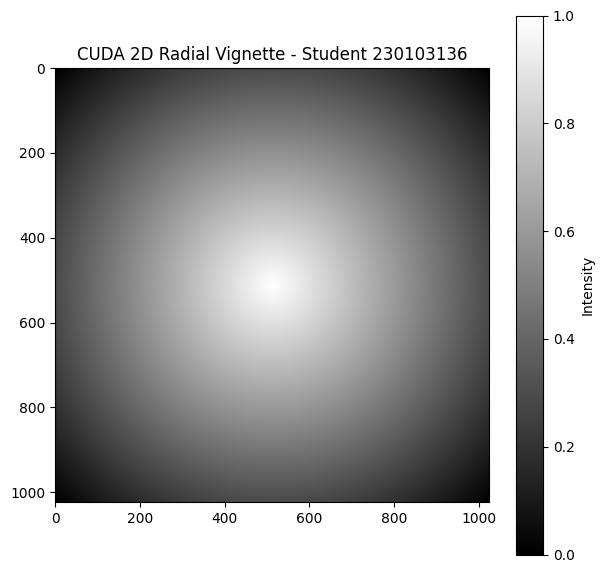

In [11]:

import numpy as np
import math
from numba import cuda
import matplotlib.pyplot as plt

@cuda.jit
def radial_vignette_2d(d_canvas, width, height, center_x, center_y):
    x, y = cuda.grid(2)

    if x < width and y < height:
        dx = float(x - center_x)
        dy = float(y - center_y)

        dist = math.sqrt(dx * dx + dy * dy)
        max_dist = math.sqrt(float(center_x**2 + center_y**2))

        intensity = 1.0 - (dist / max_dist)

        if intensity < 0.0:
            intensity = 0.0

        d_canvas[y, x] = intensity


WIDTH, HEIGHT = 1024, 1024

canvas = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
d_canvas = cuda.to_device(canvas)


threads_2d = (16, 16)

blocks_2d = (
    (WIDTH + threads_2d[0] - 1) // threads_2d[0],
    (HEIGHT + threads_2d[1] - 1) // threads_2d[1]
)


radial_vignette_2d[blocks_2d, threads_2d](
    d_canvas, WIDTH, HEIGHT, WIDTH // 2, HEIGHT // 2
)

cuda.synchronize()

result_canvas = d_canvas.copy_to_host()

print("SECTION 5 - 2D GEOMETRY RESULTS")
print("-" * 45)
print("Grid Blocks X:", blocks_2d[0])
print("Grid Blocks Y:", blocks_2d[1])
print("Total Blocks:", blocks_2d[0] * blocks_2d[1])
print("Matrix Shape:", result_canvas.shape)
print("Center Pixel:", result_canvas[512, 512])
print("Corner Pixel:", result_canvas[0, 0])


plt.figure(figsize=(7, 7))
plt.imshow(result_canvas, cmap="gray", vmin=0, vmax=1)
plt.title("CUDA 2D Radial Vignette - Student 230103136")
plt.colorbar(label="Intensity")
plt.show()


Section 6

In [12]:

import hashlib
from numba import cuda

def generate_lab_checksum(student_id_str, d_canvas, exp_table_crossover):
    h = hashlib.sha256()


    h.update(student_id_str.strip().encode('utf-8'))


    gpu_name = cuda.get_current_device().name
    if isinstance(gpu_name, str):
        gpu_name = gpu_name.encode('utf-8')
    h.update(gpu_name)


    h.update(d_canvas.copy_to_host()[:10, :10].tobytes())


    h.update(str(exp_table_crossover).encode('utf-8'))

    digest = h.hexdigest()[:16].upper()

    print("=" * 60)
    print("OFFICIAL VERIFICATION CHECKSUM TOKEN:", digest)
    print("=" * 60)

    return digest



STUDENT_ID = "230103136"


CROSSOVER_N = 10000

verification_token = generate_lab_checksum(
    STUDENT_ID,
    d_canvas,
    CROSSOVER_N
)


OFFICIAL VERIFICATION CHECKSUM TOKEN: 5C6DB3E1272D2CCB
